# EDA

**Import libraries**
Loads the core data-analysis and visualization stack: `numpy`/`pandas` for data handling and `matplotlib`/`seaborn` for plotting.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set_theme(style="whitegrid", palette="Set2")

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["figure.dpi"] = 120

**Load the dataset**
Reads the smartphone dataset from `Dataset.xlsx` into the DataFrame `df`, which is used throughout the rest of the notebook.

In [4]:
df = pd.read_excel('Dataset.xlsx')

## Dataset Overview
Dataset shape

Data types

Missing values

Duplicate values

Summary statistics (describe())

**Dataset shape**
Displays the number of rows and columns in `df` to get a quick sense of the dataset's size.

In [6]:
df.shape

(5627, 16)

**Data types**
Shows the dtype of each column, useful for confirming which fields are numeric vs. categorical/text.

In [7]:
df.dtypes

,0
Name,object
Brand,object
Price,int64
MRP,int64
Discount,int64
Rating,float64
Ratings,int64
Reviews,int64
RAM,int64
Storage,int64


**Missing values**
Counts null/NaN values per column to identify where data cleaning may be needed.

In [9]:
df.isnull().sum()

,0
Name,0
Brand,0
Price,0
MRP,0
Discount,0
Rating,0
Ratings,0
Reviews,0
RAM,0
Storage,0


**Duplicate rows**
Counts fully duplicated rows in the dataset.

In [11]:
df.duplicated().sum()

np.int64(0)

**Summary statistics**
Runs `describe()` to get count, mean, std, min/max, and quartiles for the numeric columns.

In [12]:
df.describe()

,Price,MRP,Discount,Rating,Ratings,Reviews,RAM,Storage,Battery
count,5627.000000,5627.000000,5627.000000,5627.000000,5627.000000,5627.000000,5627.000000,5627.000000,5627.000000
mean,32930.778390,37634.728452,13.912920,4.293940,31906.764528,2338.963924,6.894971,174.861205,5065.148036
std,33634.418952,35322.488957,13.996885,0.210337,64684.567466,5514.820532,2.835298,144.185328,1081.807053
min,5299.000000,5299.000000,0.000000,2.300000,2.000000,0.000000,2.000000,8.000000,1420.000000
25%,12765.500000,15499.000000,0.000000,4.200000,1067.000000,78.000000,4.000000,128.000000,4700.000000
50%,19999.000000,23999.000000,11.000000,4.300000,4871.000000,380.000000,6.000000,128.000000,5000.000000
75%,37999.000000,44999.000000,25.000000,4.400000,31207.000000,2189.000000,8.000000,256.000000,5500.000000
max,222900.000000,229900.000000,60.000000,4.800000,885818.000000,80982.000000,24.000000,2048.000000,10001.000000


### Possible Conclusion

- The dataset contains both budget and premium smartphones.
- Most smartphones are priced below ₹38,000 (75th percentile).
- Customer ratings are generally positive across products.
- Sales popularity is uneven—only a few smartphones dominate ratings and reviews.
- The typical smartphone in the dataset has 6 GB RAM, 128 GB storage, and a 5000 mAh battery, suggesting these are the market standard configurations.

## Univariate Analysis (Single Variable)

Price distribution

Rating distribution

RAM distribution

Storage distribution

Battery distribution

Discount distribution

Processor distribution

Brand distribution

**Plot styling setup**
Sets a consistent seaborn theme (`whitegrid`) and default figure size for all the plots that follow.

In [13]:
# Plot style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

**Price distribution**
Plots a histogram (with KDE) and a boxplot of `Price` side by side to visualize its distribution and spot outliers.

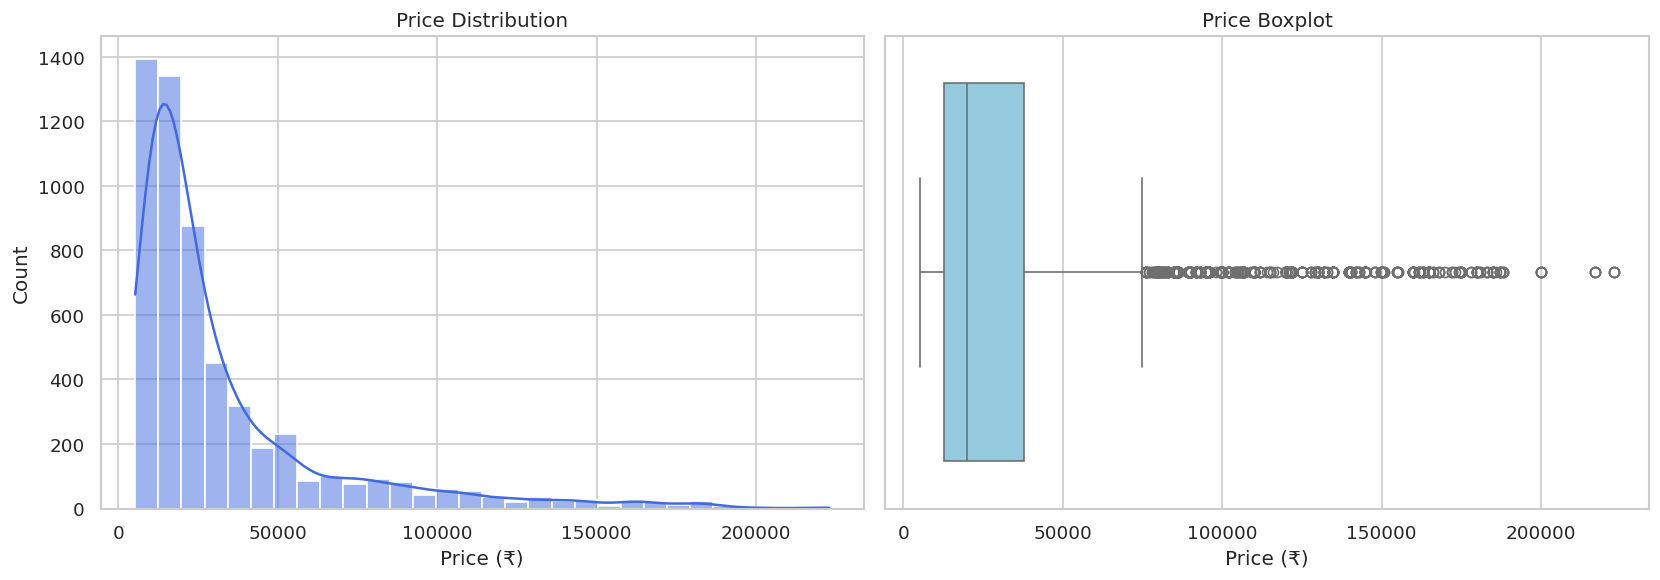

In [14]:
# 1. Price Distribution

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["Price"], bins=30, kde=True, color="royalblue", ax=ax[0])
ax[0].set_title("Price Distribution")
ax[0].set_xlabel("Price (₹)")

sns.boxplot(x=df["Price"], color="skyblue", ax=ax[1])
ax[1].set_title("Price Boxplot")
ax[1].set_xlabel("Price (₹)")

plt.tight_layout()
plt.show()

The price distribution is positively skewed, with most smartphones concentrated in the ₹10,000–₹30,000 range. The number of smartphones decreases as the price increases, indicating that the dataset is dominated by budget and mid-range devices. A small number of premium smartphones priced above ₹1,00,000 create a long right tail and act as outliers. These high-priced devices increase the average price, making the median a better indicator of the typical smartphone price.

**Rating distribution**
Plots a histogram (with KDE) of the `Rating` column.

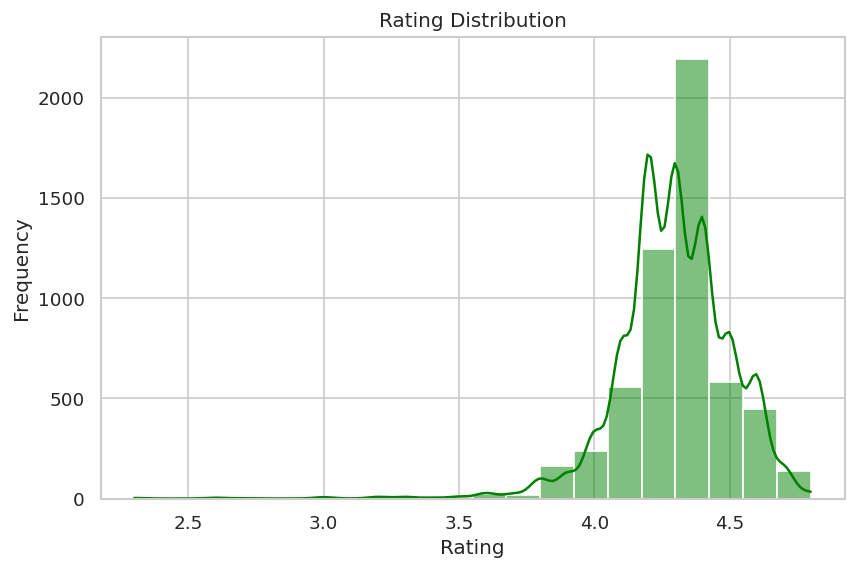

In [15]:
# 2. Rating Distribution

plt.figure(figsize=(8,5))

sns.histplot(df["Rating"], bins=20, kde=True, color="green")

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

The rating distribution is concentrated between 4.1 and 4.5, with most smartphones receiving ratings around 4.3–4.4. The distribution is slightly left-skewed, indicating that higher ratings are much more common than lower ratings. Very few smartphones have ratings below 4.0, suggesting that the majority of products are positively reviewed. The narrow spread of ratings also indicates relatively consistent customer satisfaction across different smartphone models.

**RAM distribution**
Shows a count plot of how many smartphones fall into each `RAM` (GB) category.

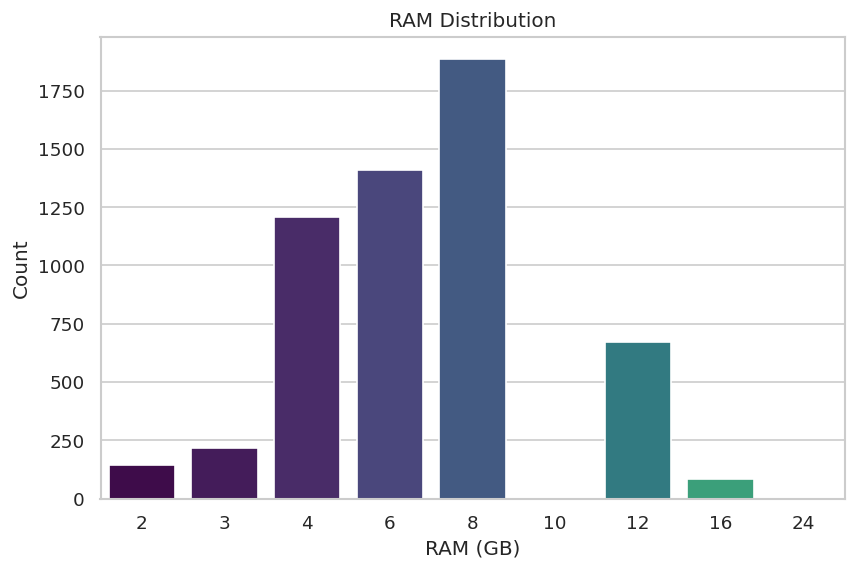

In [16]:
# 3. RAM Distribution

plt.figure(figsize=(8,5))

sns.countplot(
    x="RAM",
    hue="RAM",
    data=df,
    order=sorted(df["RAM"].unique()),
    palette="viridis",
    legend=False
)

plt.title("RAM Distribution")
plt.xlabel("RAM (GB)")
plt.ylabel("Count")

plt.show()

The RAM distribution indicates that the market is heavily concentrated around 8 GB configurations, suggesting it is the optimal balance between affordability and performance. While premium devices with 12 GB or more RAM exist, their adoption remains limited due to higher costs and lower consumer requirements.

**Storage distribution**
Shows a count plot of how many smartphones fall into each `Storage` (GB) category.

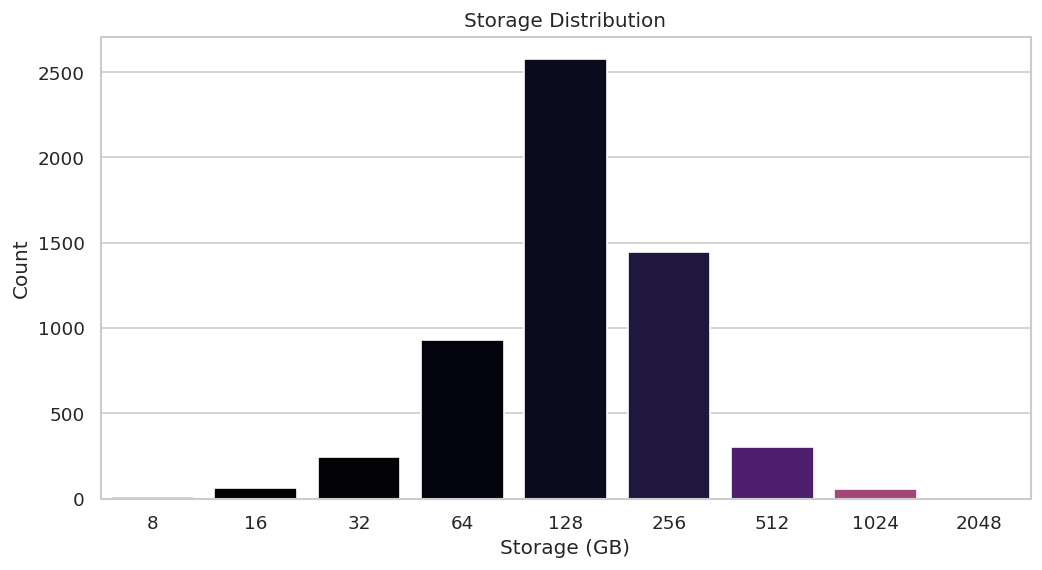

In [17]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="Storage",
    hue="Storage",
    data=df,
    order=sorted(df["Storage"].unique()),
    palette="magma",
    legend=False
)

plt.title("Storage Distribution")
plt.xlabel("Storage (GB)")
plt.ylabel("Count")
plt.show()

The storage distribution shows that 128 GB is the market standard, with 256 GB emerging as the preferred upgrade option. Lower capacities below 64 GB have limited adoption due to increasing storage requirements, while ultra-high storage configurations remain niche products targeted at premium users.

**Battery distribution**
Plots a histogram (with KDE) of `Battery` capacity (mAh).

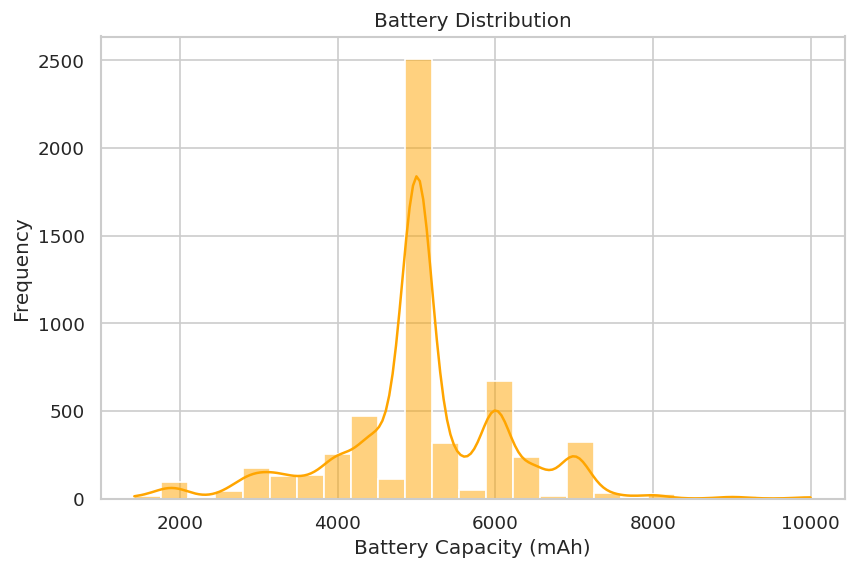

In [18]:
# 5. Battery Distribution

plt.figure(figsize=(8,5))

sns.histplot(df["Battery"], bins=25, kde=True, color="orange")

plt.title("Battery Distribution")
plt.xlabel("Battery Capacity (mAh)")
plt.ylabel("Frequency")

plt.show()

The battery distribution shows that 5000 mAh is the market sweet spot, dominating modern devices. Manufacturers have standardized around 4000–5000 mAh batteries to balance performance, cost, and device design. Larger batteries above 6000 mAh remain niche, while lower-capacity batteries have declining adoption due to increasing power demands.

**Discount distribution**
Plots a histogram (with KDE) of the `Discount` (%) column.

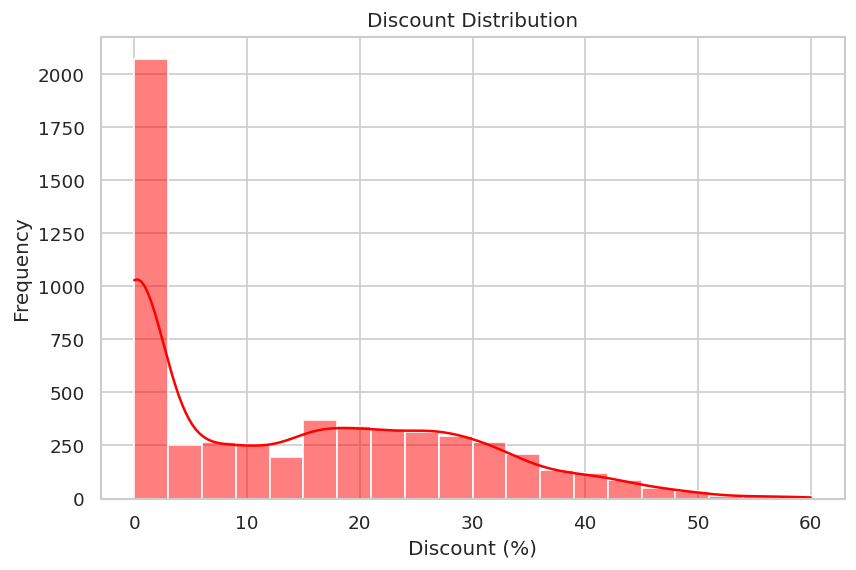

In [19]:
# 6. Discount Distribution

plt.figure(figsize=(8,5))

sns.histplot(df["Discount"], bins=20, kde=True, color="red")

plt.title("Discount Distribution")
plt.xlabel("Discount (%)")
plt.ylabel("Frequency")

plt.show()

The discount distribution shows that most products either have no discount or moderate discounts between 10–30%. Sellers generally avoid extreme price cuts, indicating a strategy focused on maintaining product value while using moderate discounts to attract customers.

**Top 10 processors**
Computes the 10 most frequent values in `Processor` and displays them as a bar chart.

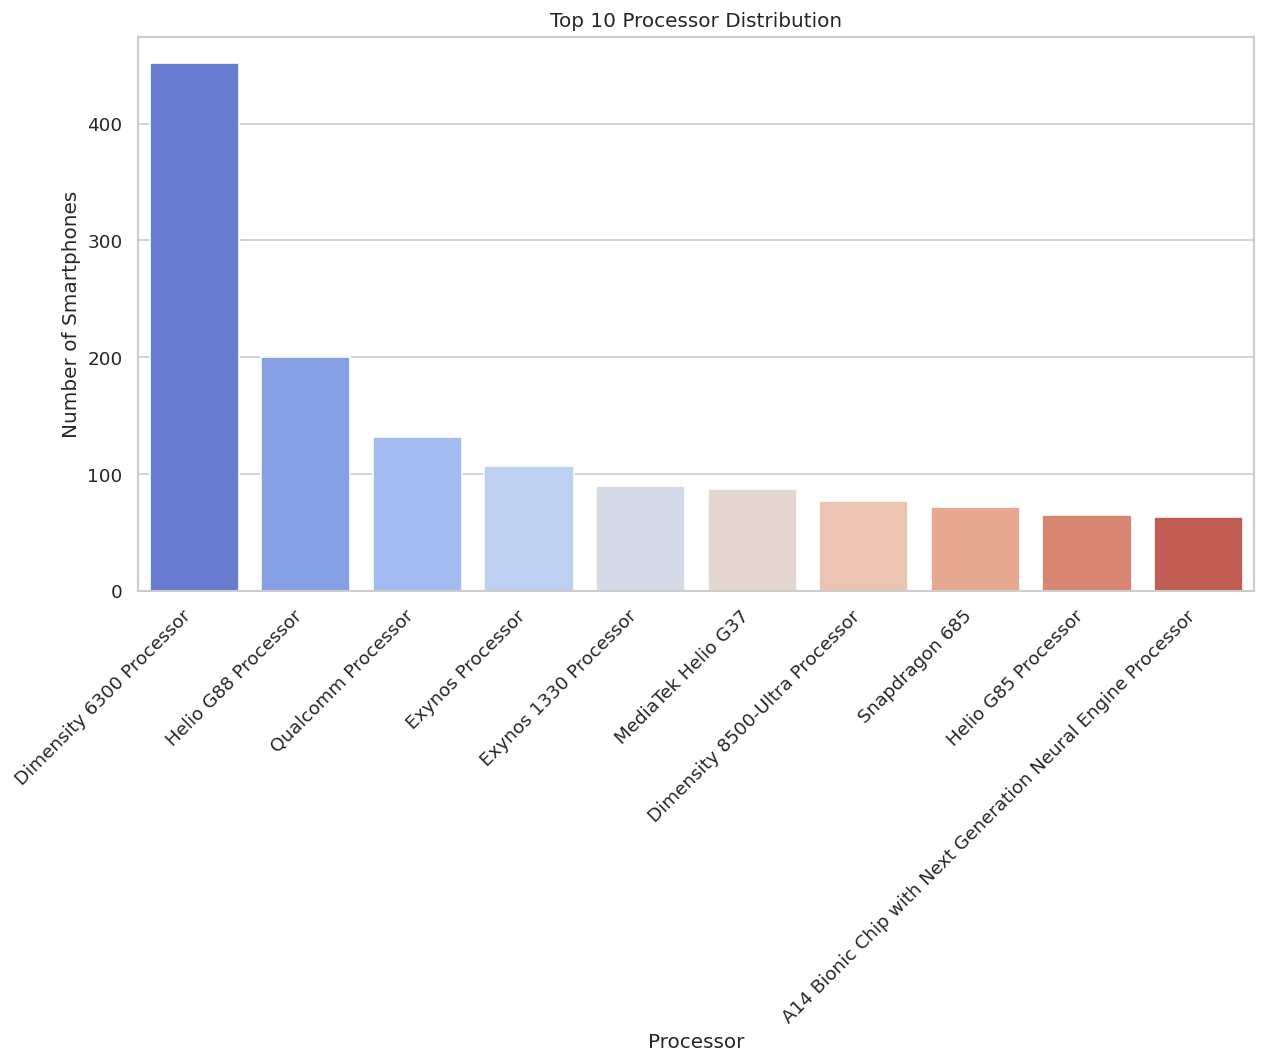

In [20]:
# 7. Processor Distribution (Top 10)

top_processors = df["Processor"].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_processors.index,
    y=top_processors.values,
    hue=top_processors.index,
    palette="coolwarm",
    legend=False
)

plt.title("Top 10 Processor Distribution")
plt.xlabel("Processor")
plt.ylabel("Number of Smartphones")

plt.xticks(rotation=45, ha="right")

plt.show()

The processor distribution shows that MediaTek-based chipsets dominate smartphone availability, with Dimensity 6300 emerging as the most common processor. The market is concentrated around budget and mid-range processors, while premium chipsets have comparatively lower representation.

**Brand distribution**
Counts smartphones per `Brand` and displays them as a bar chart.

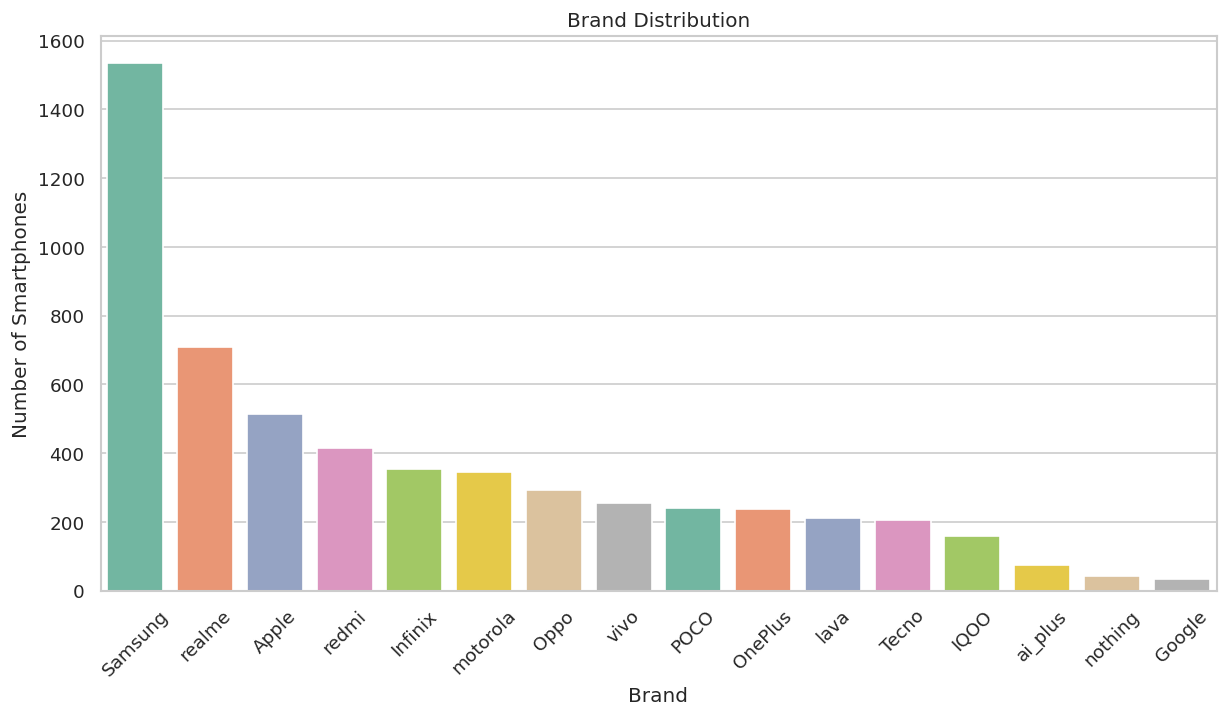

In [21]:
# 8. Brand Distribution

brand_counts = df["Brand"].value_counts()

plt.figure(figsize=(12,6))

sns.barplot(
    x=brand_counts.index,
    y=brand_counts.values,
    hue=brand_counts.index,
    palette="Set2",
    legend=False
)

plt.title("Brand Distribution")
plt.xlabel("Brand")
plt.ylabel("Number of Smartphones")

plt.xticks(rotation=45)

plt.show()

The brand distribution shows Samsung as the dominant player, followed by Realme and Apple. The market is concentrated around a few major brands, while mid-range competitors such as Redmi, Infinix, Motorola, and POCO create a highly competitive value segment. Smaller brands occupy niche markets rather than mass adoption.

**Automated EDA report (Sweetviz)**
Uses the `sweetviz` library to auto-generate a full exploratory data analysis report object (`iris_report`) for `df`.

In [23]:
import sweetviz as sv
iris_report = sv.analyze(df)
iris_report

                                             |          | [  0%]   00:00 -> (? left)

**Export Sweetviz report**
Saves the generated Sweetviz report to an HTML file, `Report1.html`, for standalone viewing.

In [24]:
iris_report.show_html('Report1.html')

Report Report1.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


## Bivariate Analysis (Two Variables)

Price vs RAM

Price vs Storage

Price vs Battery

Price vs Rating

Rating vs Reviews

Brand vs Price

Brand vs Rating

RAM vs Rating

**Price vs RAM**
Boxplot comparing `Price` across different `RAM` capacities to check for a relationship between the two.

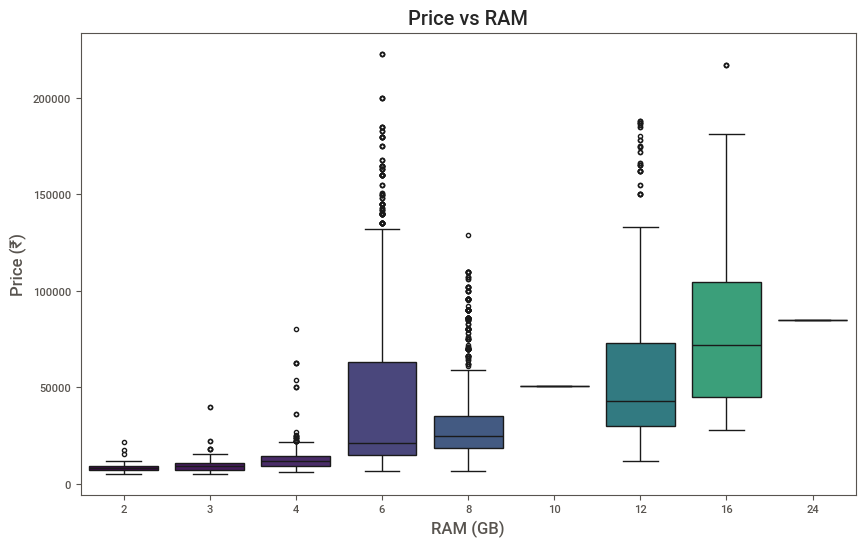

In [25]:
# Price Vs RAM

plt.figure(figsize=(10,6))

sns.boxplot(
    x="RAM",
    y="Price",
    data=df,
    hue="RAM",
    palette="viridis",
    legend=False
)

plt.title("Price vs RAM")
plt.xlabel("RAM (GB)")
plt.ylabel("Price (₹)")

plt.show()

The boxplot shows a clear positive relationship between RAM capacity and Smartphone price. As RAM increases, the median price generally rises. Higher RAM categories (6 GB, 12 GB, and 16 GB) exhibit greater price variability and numerous high-value outliers, indicating that additional hardware features beyond RAM significantly influence Smartphone pricing. Lower RAM categories (2 GB and 3 GB) are concentrated in the budget segment with relatively stable prices, while categories like 10 GB and 24 GB contain too few observations for reliable conclusions.

**Price vs Storage**
Boxplot comparing `Price` across different `Storage` capacities.

/tmp/ipykernel_5309/1488435624.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


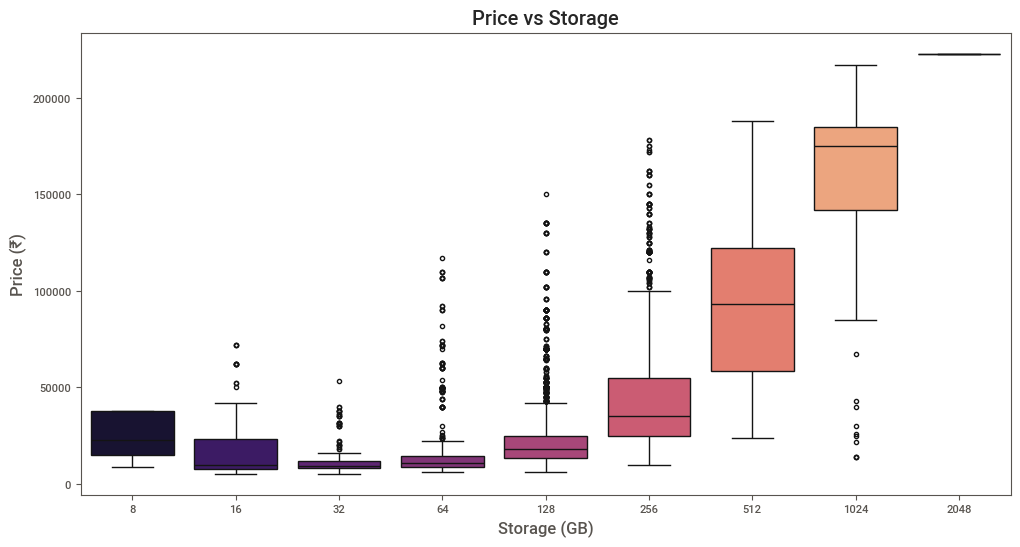

In [26]:
# Price Vs Storage

plt.figure(figsize=(12,6))

sns.boxplot(
    x="Storage",
    y="Price",
    data=df,
    palette="magma"
)

plt.title("Price vs Storage")
plt.xlabel("Storage (GB)")
plt.ylabel("Price (₹)")

plt.show()

The boxplot indicates a positive relationship between storage capacity and Smartphone price. Higher storage capacities generally correspond to higher median prices, particularly for 512 GB, 1 TB, and 2 TB configurations. Price variability increases with storage size, suggesting that storage is only one of several factors influencing Smartphone pricing. Categories such as 256 GB and 512 GB exhibit wide price distributions because they include Smartphone from budget to premium segments. Several storage groups also contain high-price outliers, indicating that premium hardware configurations can significantly increase prices even when storage capacity is moderate.

**Price vs Battery**
Scatterplot of `Battery` capacity against `Price` to check for any correlation.

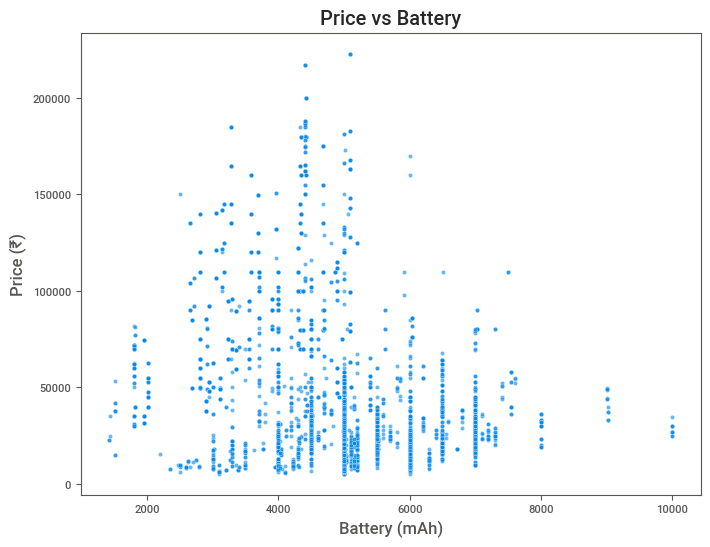

In [27]:
# Price Vs battery

plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Battery",
    y="Price",
    data=df,
    alpha=0.6
)

plt.title("Price vs Battery")
plt.xlabel("Battery (mAh)")
plt.ylabel("Price (₹)")

plt.show()

Battery capacity has a weak correlation with smartphone price.
Most smartphones feature 4,000–6,000 mAh batteries regardless of price segment.
The 4,500–5,000 mAh range contains the greatest variety of smartphone prices.
Premium smartphones often use 4,000–5,000 mAh batteries instead of extremely large batteries.
Smartphones with 6,000 mAh or higher are not necessarily expensive.
Battery capacity alone is not a reliable predictor of smartphone price; other hardware specifications and brand positioning play a much larger role.

**Price vs Rating**
Regression plot (scatter + fitted line) of `Rating` against `Price`.

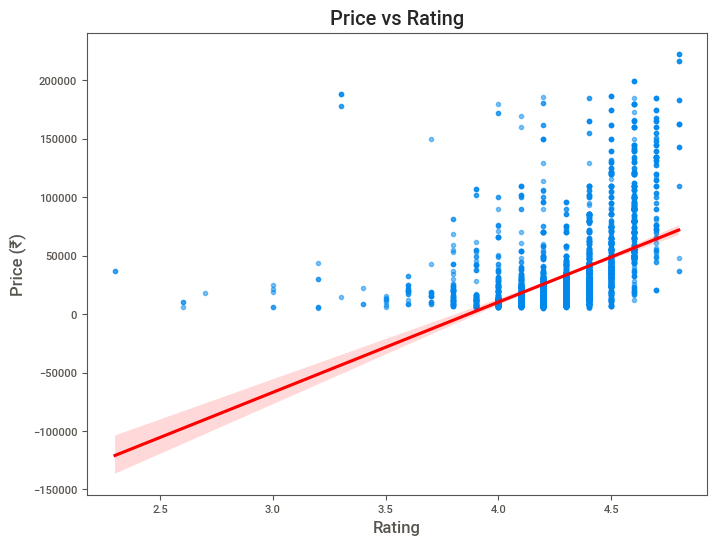

In [28]:
# Price Vs Rating

plt.figure(figsize=(8,6))

sns.regplot(
    x="Rating",
    y="Price",
    data=df,
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)

plt.title("Price vs Rating")
plt.xlabel("Rating")
plt.ylabel("Price (₹)")

plt.show()

Smartphone ratings show a moderate positive correlation with price.
Most smartphones are rated between 4.0 and 4.7, indicating generally positive customer feedback.
Higher-rated smartphones are found across budget, mid-range, and premium segments.
Premium smartphones typically receive higher customer ratings, but high ratings are not exclusive to expensive devices.
Rating is not a strong standalone predictor of price; other hardware specifications and brand reputation also play a significant role.

**Rating vs Reviews**
Scatterplot of number of `Reviews` against `Rating`.

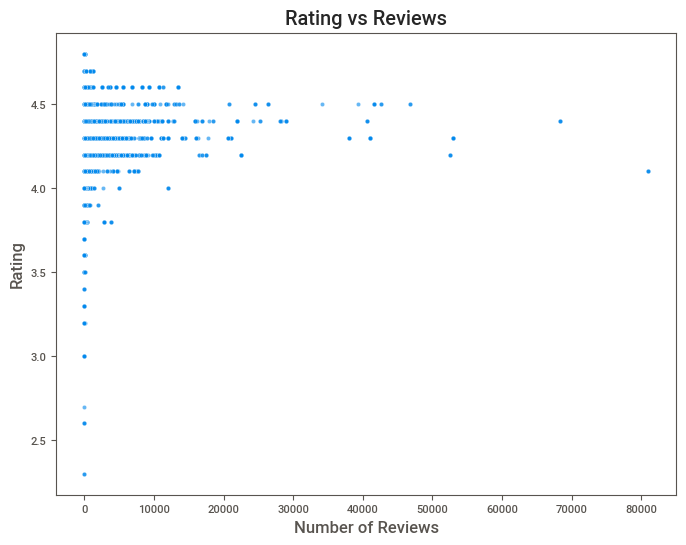

In [29]:
# Ratings Vs Revies

plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Reviews",
    y="Rating",
    data=df,
    alpha=0.6
)

plt.title("Rating vs Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Rating")

plt.show()

Most smartphones have ratings between 4.1 and 4.5.
The number of reviews varies widely across smartphones.
Highly reviewed smartphones generally maintain good customer ratings (4.1–4.5).
There is no strong correlation between the number of reviews and rating.
Most smartphones receive fewer than 15,000 reviews, while only a few models achieve exceptionally high review counts.
High review counts likely indicate popular or best-selling smartphones, rather than guaranteeing the highest ratings.

**Brand vs Price**
Boxplot comparing `Price` distributions across each `Brand`.

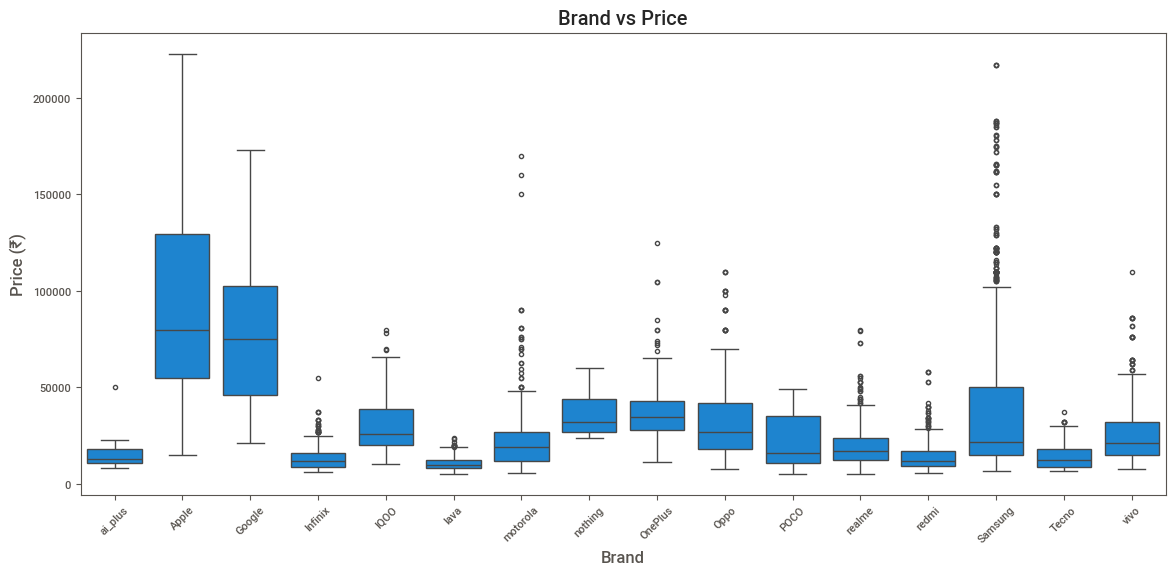

In [30]:
# brand Vs Price

plt.figure(figsize=(14,6))

sns.boxplot(
    x="Brand",
    y="Price",
    data=df
)

plt.xticks(rotation=45)

plt.title("Brand vs Price")
plt.xlabel("Brand")
plt.ylabel("Price (₹)")

plt.show()

Smartphone prices vary significantly by brand.
Apple has the highest median price, reflecting its premium positioning.
Google also primarily targets the premium smartphone market.
Samsung has the widest price range, covering budget to flagship devices.
OnePlus and Nothing mainly compete in the upper mid-range and premium segments.
Lava, Infinix, Redmi, Tecno, and AI+ are largely budget-focused brands.
Several brands have premium-priced outliers, showing that flagship models command significantly higher prices.
Brand positioning is a strong factor influencing smartphone prices, alongside specifications such as RAM, storage, processor, and camera quality.

**Brand vs Rating**
Boxplot comparing `Rating` distributions across each `Brand`.

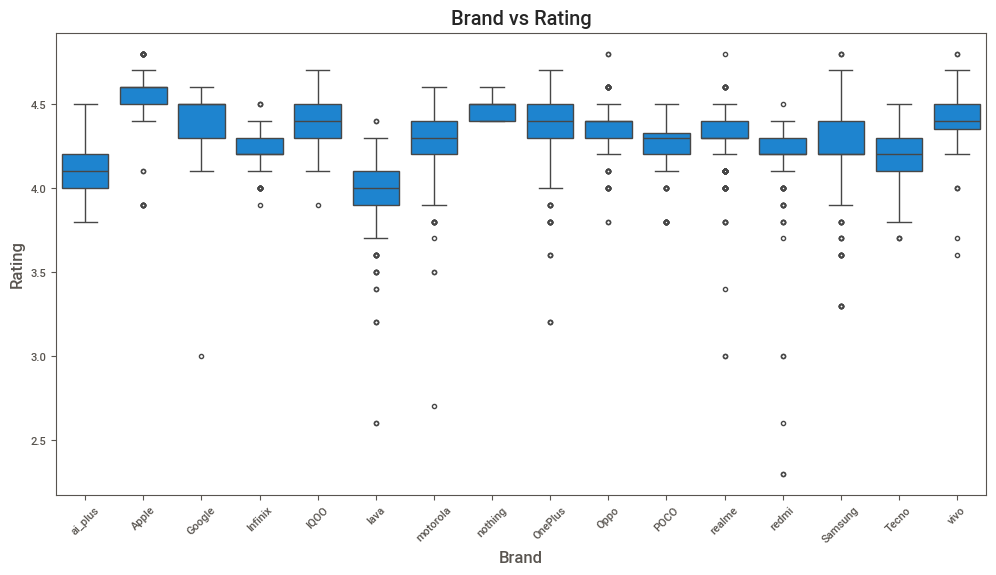

In [31]:
# Brand vs Rating

plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='Brand', y='Rating')
plt.xticks(rotation=45)
plt.title("Brand vs Rating")
plt.show()

Most smartphone brands have median ratings between 4.2 and 4.5, indicating generally positive customer satisfaction.
Apple, Nothing, OnePlus, iQOO, and vivo have some of the highest and most consistent ratings.
Lava has the lowest median rating and greater variation in customer feedback.
Budget brands like Infinix, Redmi, and Tecno also maintain strong customer ratings despite lower price points.
Several brands contain low-rating and high-rating outliers, reflecting differences in the performance of individual smartphone models.
Brand influences customer ratings, but premium pricing does not necessarily guarantee significantly higher ratings.

**RAM vs Rating**
Scatterplot of `RAM` against `Rating`.

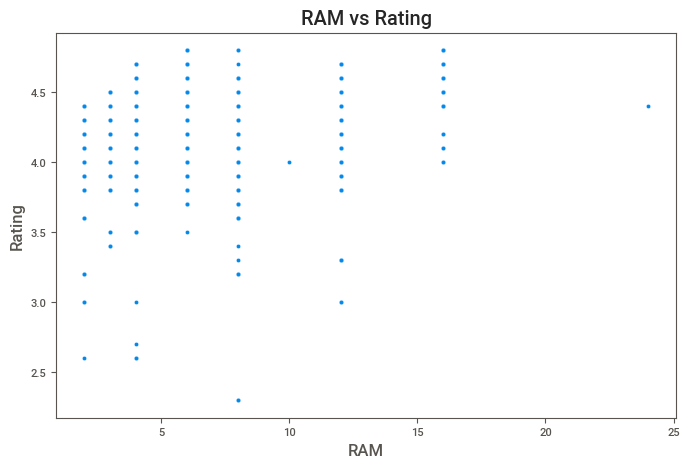

In [32]:
# RAM vs Rating

sns.scatterplot(data=df, x='RAM', y='Rating')
plt.title("RAM vs Rating")
plt.show()

Increasing RAM alone is unlikely to improve customer ratings.
Manufacturers should also focus on software optimization, battery life, cameras, display quality, and overall user experience.
8 GB RAM offers a good balance between cost and customer satisfaction, making it a strong mainstream option.
Flagship devices (12–16 GB RAM) generally maintain high customer satisfaction, indicating consistent premium quality.

**Correlation matrix**
Selects numeric columns and computes the pairwise Pearson correlation matrix, printed as a table.

In [33]:
num_df = df.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
corr_matrix = num_df.corr()

print(corr_matrix)

             Price       MRP  Discount    Rating   Ratings   Reviews  \
Price     1.000000  0.978641 -0.280102  0.482711 -0.094943 -0.089050   
MRP       0.978641  1.000000 -0.127591  0.472387 -0.116519 -0.108920   
Discount -0.280102 -0.127591  1.000000 -0.170737 -0.091273 -0.110103   
Rating    0.482711  0.472387 -0.170737  1.000000  0.149540  0.119895   
Ratings  -0.094943 -0.116519 -0.091273  0.149540  1.000000  0.926586   
Reviews  -0.089050 -0.108920 -0.110103  0.119895  0.926586  1.000000   
RAM       0.395859  0.450268  0.051263  0.299722 -0.208648 -0.194125   
Storage   0.654894  0.669812 -0.053491  0.356537 -0.144933 -0.151153   
Battery  -0.294305 -0.261670  0.207310 -0.100925 -0.159249 -0.170061   

               RAM   Storage   Battery  
Price     0.395859  0.654894 -0.294305  
MRP       0.450268  0.669812 -0.261670  
Discount  0.051263 -0.053491  0.207310  
Rating    0.299722  0.356537 -0.100925  
Ratings  -0.208648 -0.144933 -0.159249  
Reviews  -0.194125 -0.151153 -0.1

**Correlation heatmap**
Visualizes the correlation matrix computed above as an annotated heatmap.

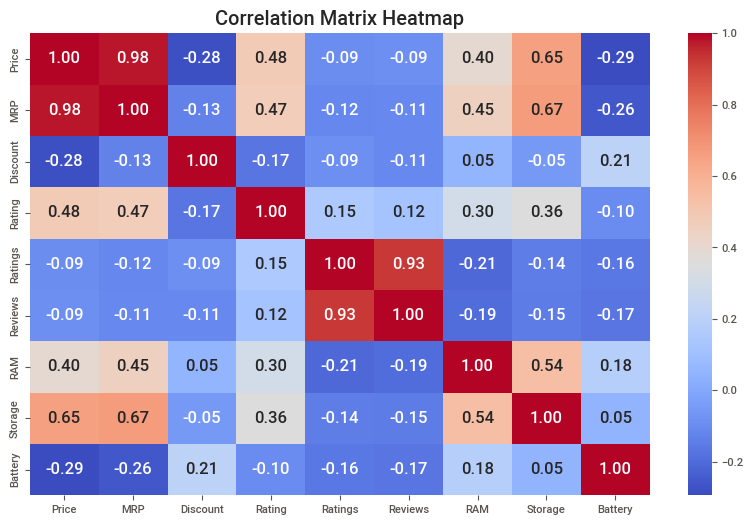

In [34]:
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()

**Pairplot of key numeric features**
Generates pairwise scatterplots (and diagonal distributions) for `Price`, `RAM`, `Storage`, `Battery`, `Rating`, and `Reviews` to spot relationships across multiple variables at once.

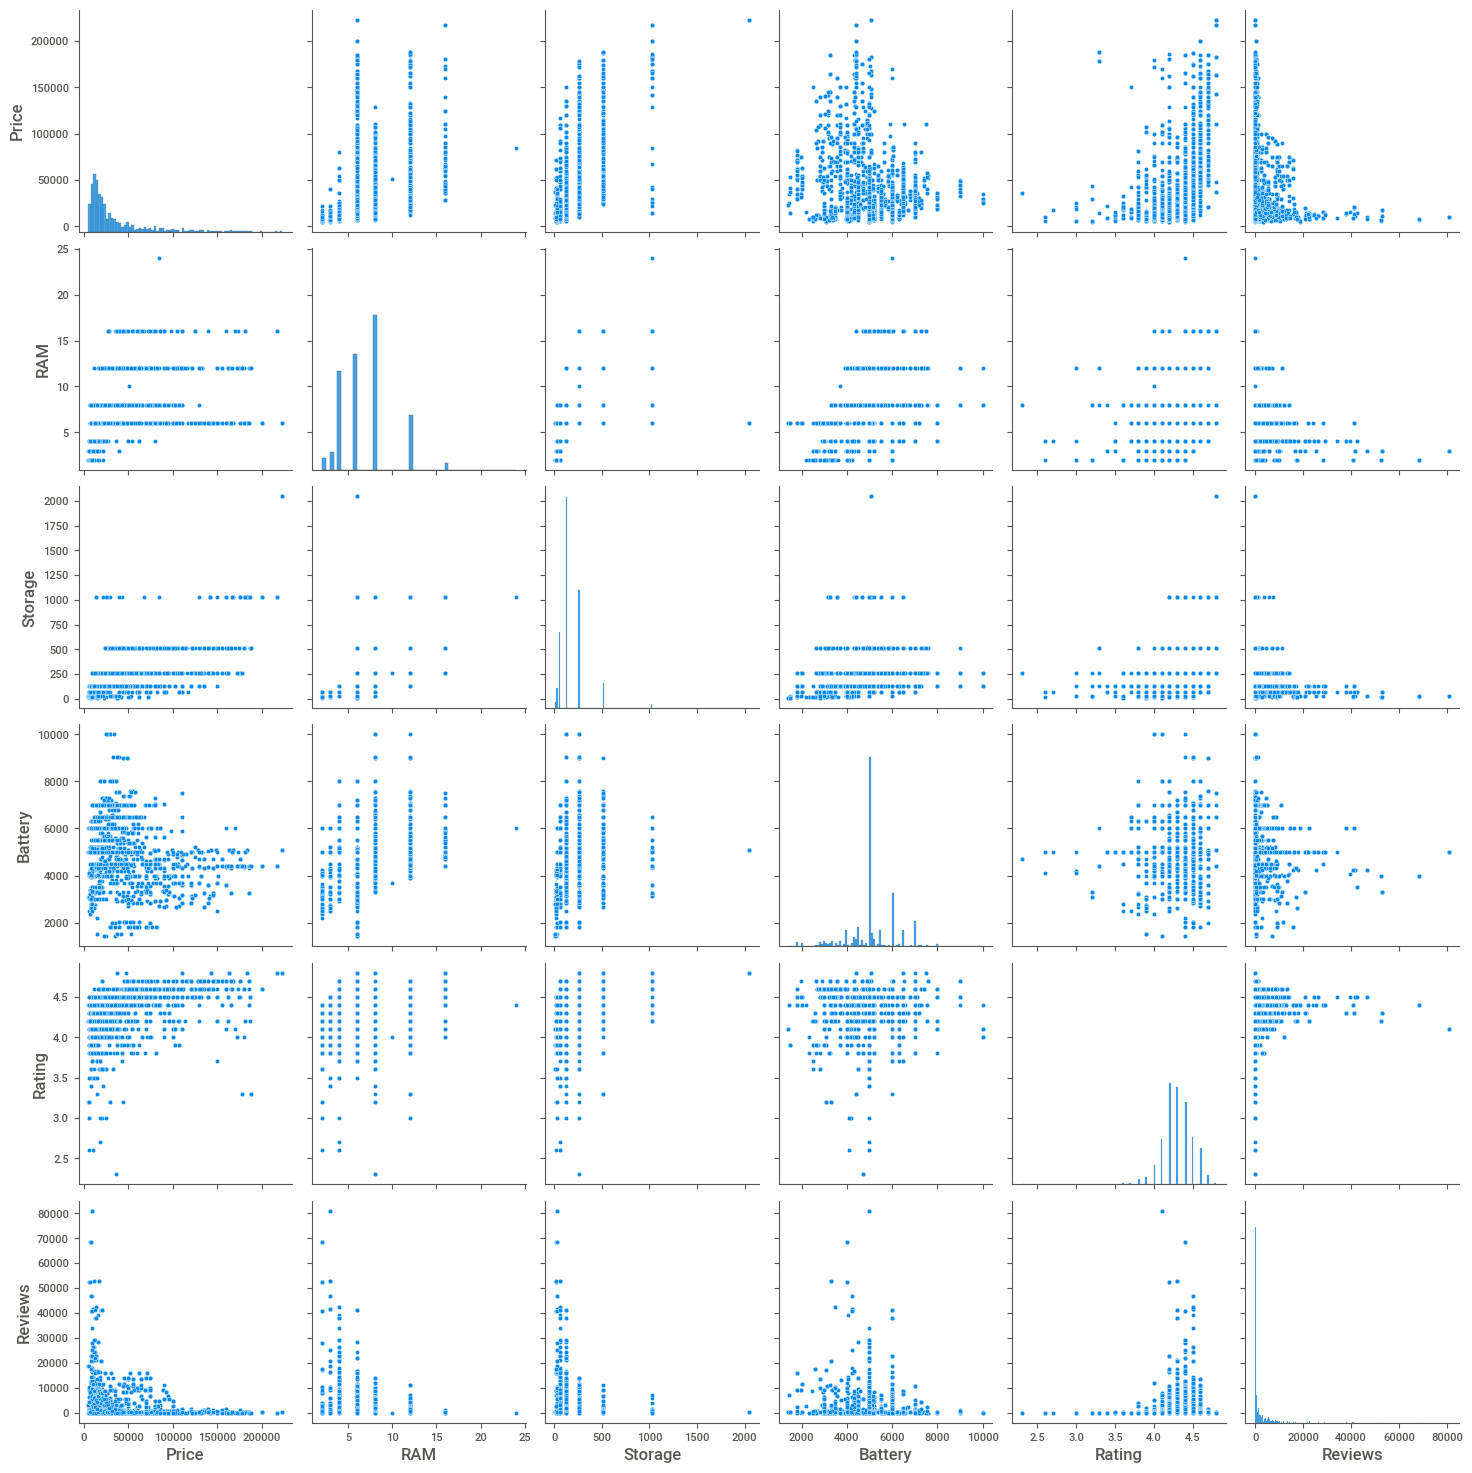

In [35]:
sns.pairplot(df[['Price', 'RAM', 'Storage', 'Battery', 'Rating', 'Reviews']])
plt.show()

**Price, RAM, and Storage together**
Scatterplot of `RAM` vs `Price`, with point size and color both mapped to `Storage`, to explore how three variables interact simultaneously.